# Multi-Touch Attribution Comparison: Last-Touch vs. Linear vs. Time-Decay

*Dataset: `bigquery-public-data.ga4_obfuscated_sample_ecommerce` (BigQuery, Google Merchandise Store)*

Don't blindly trust last-click. If you're only giving credit to the channel or source your customer came from right before purchasing, you might be skipping much of the journey it took to get them there in the first place. In this project, I challenge that assumption: I extracted three months of Google Merchandise Store data from BigQuery and built three different attribution models to see how each one represented channel contribution.

## Key Decisions

### Is It Worth Building?

Before doing anything else, I had to decide whether building multiple attribution models was even worthwhile. If the large majority of conversions in this three-month period were single-touch (only one session before conversion), the results of every model would look basically identical to Last-Touch. Querying session counts per purchaser directly in BigQuery, I found **2,084 (47%) single-session purchasers** and **2,335 (53%) multi-session purchasers**, confirming there was enough multi-touch behavior in the data to make attribution modeling meaningful.

### First-Purchase Scoping and Extraction

The raw dataset (`bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`) is event-level: every row is a single event (e.g. clicking a product, adding to cart), tied to a specific user, session, and the channel/source associated with that session. For attribution modeling, I only cared about session-level data: how many sessions it took to convert, and the source/channel tied to each one.

I filtered to sessions up to and including each user's first purchase (behavior after that point can be explained by other factors, like prior brand experience or remarketing). My first extraction anchored each session to its `session_start` event, but that event turned out to be unreliable: some sessions never generated one at all, causing 62 purchasers (~1.4% of the population) to disappear entirely. The fix: rank each session's events by timestamp and anchor to whichever event happened first, regardless of type. The query below, run directly in BigQuery, produced the CSV loaded in this notebook:

```sql
WITH first_purchase AS (
  SELECT user_pseudo_id, MIN(event_timestamp) AS first_purchase_ts
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
  WHERE event_name = "purchase"
  GROUP BY user_pseudo_id
),
pre_purchase_events AS (
  SELECT
    e.user_pseudo_id,
    (SELECT value.int_value FROM UNNEST(e.event_params) WHERE key = "ga_session_id") AS session_id,
    e.event_timestamp,
    e.traffic_source.source AS source,
    e.traffic_source.medium AS medium
  FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*` e
  JOIN first_purchase p ON e.user_pseudo_id = p.user_pseudo_id
  WHERE e.event_timestamp <= p.first_purchase_ts
),
ranked AS (
  SELECT
    *,
    ROW_NUMBER() OVER (PARTITION BY user_pseudo_id, session_id ORDER BY event_timestamp ASC) AS rn
  FROM pre_purchase_events
)
SELECT user_pseudo_id, session_id, event_timestamp, source, medium
FROM ranked
WHERE rn = 1
ORDER BY user_pseudo_id, event_timestamp
```

**Single-session buy:** one user, one row, with the source being the attributed traffic source.
**Multi-session buy:** one user, multiple rows, with the last row being the converting session's traffic source.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

df = pd.read_csv("google_merch_data.csv")
df.head(10)

,user_pseudo_id,session_id,event_timestamp,source,medium
0,1.009293e+07,8014902521,1611293016291786,(direct),(none)
1,1.011106e+07,6975932005,1607602735718750,google,organic
2,1.014825e+06,2716419230,1604389487992214,<Other>,organic
3,1.016447e+06,9359060345,1608542839639574,google,organic
4,1.016447e+06,2633554037,1608550202947307,google,organic
5,1.017285e+07,4974585843,1607498064354453,(direct),(none)
6,1.019528e+06,9903438389,1607127735351596,google,organic
7,1.021147e+07,7865914567,1604998136495803,<Other>,referral
8,1.021147e+07,2667463866,1608282615595666,<Other>,referral
9,1.021147e+07,4855749522,1608288263818636,(direct),(none)


In [2]:
df.shape

(10317, 5)

In [3]:
df.columns

Index(['user_pseudo_id', 'session_id', 'event_timestamp', 'source', 'medium'], dtype='object')

In [4]:
df["source"].value_counts()

source
google                             3030
<Other>                            2273
(direct)                           2271
(data deleted)                     1483
shop.googlemerchandisestore.com    1260
Name: count, dtype: int64

In [5]:
df["medium"].value_counts()

medium
organic           2934
referral          2283
(none)            2271
(data deleted)    1509
<Other>           1000
cpc                320
Name: count, dtype: int64

## Cleaning Source and Medium Data

Two placeholder values show up above in `source` and `medium`: `<Other>` and `(data deleted)`. Both indicate GA4 obfuscation rather than a real channel. They make up too large a share of the data to simply drop (that would bias every model), but they're also not actionable on their own since a marketer can't shift budget toward a channel labeled unknown.

My first pass collapsed a touchpoint to `Unknown / redacted` any time *either* `source` or `medium` held one of these placeholder values, which absorbed around 36% of last-touch credit into a single unhelpful bucket. Digging into the actual value combinations, I found 1,247 rows where `source = <Other>` but `medium` held a real, informative value (e.g. `organic`, `referral`), meaning I was discarding real information whenever only one side of the pair was bad.

I switched to a stricter rule: only collapse to `Unknown / redacted` when *both* fields are unattributable. Otherwise, keep whatever's known (e.g. source = `<Other>`, medium = `organic` becomes channel = `Unknown source / organic`). This keeps as much real signal as possible without letting the channel field become misleading.

In [6]:
# event_timestamp is in microseconds since epoch (GA4 standard) -- convert to real datetime
df["event_time"] = pd.to_datetime(df["event_timestamp"], unit="us")

def clean_channel(source, medium):
    source = str(source)
    medium = str(medium)
    unknown_values = {"(data deleted)", "<Other>", "nan"}

    source_unknown = source in unknown_values
    medium_unknown = medium in unknown_values

    if source_unknown and medium_unknown:
        return "Unknown / redacted"
    if source_unknown and not medium_unknown:
        return f"Unknown source / {medium}"
    if medium_unknown and not source_unknown:
        return f"{source} / Unknown medium"
    return f"{source} / {medium}"

df["channel"] = df.apply(lambda row: clean_channel(row["source"], row["medium"]), axis=1)

## Creating Ordered, Per-User Paths

With a clean `channel` field, I can build each user's touchpoint history: the ordered sequence of channels they encountered before converting.

In [7]:
# Sort so each user's touchpoints are in chronological order
df = df.sort_values(["user_pseudo_id", "event_time"])

# Build the ordered path per user: a list of channels, in the order they occurred
paths = (
    df.groupby("user_pseudo_id")["channel"]
    .apply(list)      # turns the grouped channel values into a list
    .reset_index()    # turns user_pseudo_id back into a normal column, not an index
    .rename(columns={"channel": "path"})
)

paths.head(10)

,user_pseudo_id,path
0,1.014825e+06,[Unknown source / organic]
1,1.016447e+06,"[google / organic, google / organic]"
2,1.019528e+06,[google / organic]
3,1.021887e+06,[(direct) / (none)]
4,1.026932e+06,[Unknown / redacted]
5,1.033086e+06,"[Unknown / redacted, Unknown source / referral..."
6,1.043539e+06,"[Unknown / redacted, Unknown / redacted]"
7,1.051154e+06,[google / organic]
8,1.052482e+06,[Unknown source / referral]
9,1.052856e+06,"[Unknown source / organic, shop.googlemerchand..."


In [8]:
# Sanity check before modeling
print(paths.shape)  # should be (4419, 2) -- one row per purchaser
print(paths["path"].apply(len).value_counts().sort_index())  # path length distribution

(4419, 2)
path
1     2084
2      897
3      575
4      345
5      202
6      131
7       72
8       46
9       27
10      22
11      13
12       5
Name: count, dtype: int64


## Last-Touch and Linear Attribution Models

In [9]:
def last_click_credit(path):
    """100% of credit goes to the last touchpoint in the path (Last-Touch model)."""
    credit = defaultdict(float)
    credit[path[-1]] = 1.0
    return credit

def linear_credit(path):
    """Credit split evenly across every touchpoint in the path (Linear model)."""
    credit = defaultdict(float)
    weight = 1.0 / len(path)
    for channel in path:
        credit[channel] += weight
    return credit

def aggregate_credit(paths_series, credit_fn):
    """Apply a credit function to every path and sum credit by channel across all users."""
    totals = defaultdict(float)
    for path in paths_series:
        for channel, value in credit_fn(path).items():
            totals[channel] += value
    return pd.Series(totals).sort_values(ascending=False)

last_click_result = aggregate_credit(paths["path"], last_click_credit)
linear_result = aggregate_credit(paths["path"], linear_credit)

comparison = pd.DataFrame({
    "last_click": last_click_result,
    "linear": linear_result
}).fillna(0)

comparison["last_click_pct"] = comparison["last_click"] / comparison["last_click"].sum() * 100
comparison["linear_pct"] = comparison["linear"] / comparison["linear"].sum() * 100

comparison.sort_values("last_click_pct", ascending=False)

,last_click,linear,last_click_pct,linear_pct
google / organic,1158.0,1253.638059,26.205024,28.369270
Unknown / redacted,1089.0,1012.530231,24.643585,22.913108
(direct) / (none),985.0,992.339574,22.290111,22.456202
shop.googlemerchandisestore.com / referral,524.0,458.650036,11.857886,10.379046
Unknown source / referral,431.0,423.299820,9.753338,9.579086
google / cpc,146.0,172.862807,3.303915,3.911808
Unknown source / organic,86.0,105.679473,1.946142,2.391479


Roughly 75% of conversions are attributable to a known channel; the remaining ~25% (`Unknown / redacted`) reflects dataset obfuscation rather than a real traffic source.

Comparing the two models: `google / organic` gets 26.2% of credit under Last-Touch versus 28.4% under Linear, meaning Last-Touch assigns it less credit than Linear does, consistent with organic functioning as an early-funnel channel. `shop.googlemerchandisestore.com / referral` shows the opposite pattern (11.9% Last-Touch vs. 10.4% Linear): Last-Touch assigns it *more* credit, consistent with referral functioning as a late-funnel, closing channel.

I'll check each channel's actual position in the funnel next, to see if this pattern holds up independently of the models themselves.

In [10]:
def position_stats(paths_series):
    """For each channel, what fraction of its appearances are as the LAST touch vs. an earlier touch?"""
    last_counts = defaultdict(int)
    total_counts = defaultdict(int)
    for path in paths_series:
        for i, channel in enumerate(path):
            total_counts[channel] += 1
            if i == len(path) - 1:
                last_counts[channel] += 1

    stats = pd.DataFrame({
        "total_appearances": pd.Series(total_counts),
        "times_last_touch": pd.Series(last_counts)
    }).fillna(0)
    stats["pct_as_last_touch"] = stats["times_last_touch"] / stats["total_appearances"] * 100
    return stats.sort_values("pct_as_last_touch")

# Filter to multi-touch paths only, so single-touch users (who are trivially
# 100% "last touch") don't dilute the signal
multi_touch_paths = paths["path"][paths["path"].apply(len) > 1]

stats = position_stats(multi_touch_paths)
stats

,total_appearances,times_last_touch,pct_as_last_touch
google / cpc,213,39,18.309859
Unknown source / organic,170,32,18.823529
google / organic,2048,496,24.218750
(direct) / (none),1775,489,27.549296
Unknown source / referral,832,240,28.846154
Unknown / redacted,2091,671,32.089909
shop.googlemerchandisestore.com / referral,1104,368,33.333333


`google / cpc` and `google / organic` are both early-funnel touchpoints (low `pct_as_last_touch`) that would get little credit under a Last-Touch model. Referral sits at the opposite end, closing out roughly 30% of the time it appears, meaning it gets a boost in credit specifically because Last-Touch rewards whichever channel happens to close.

`google / organic` touchpoints appear across 2,218 sessions but serve as the final touch only ~19-24% of the time, confirming it functions primarily as an early-funnel discovery channel. Referral touchpoints show the opposite pattern, closing out purchases at nearly double that rate (29-33%). Last-Touch attribution, by construction, can only ever credit the final touch, so it will structurally assign less credit to organic's actual role in the funnel and more to referral's, regardless of how much real influence each channel has.

Paid search (`cpc`) shows the same pattern as organic: despite costing money per click, it functions almost entirely as an early-funnel discovery channel here, rarely closing the sale directly. That's the kind of finding that would actually change a real budget conversation: if CPC is being paid for and then judged solely on Last-Touch conversions, it's likely getting less credit than its early-funnel contribution would justify.

## Time-Decay Model

In [11]:
# Need timestamps for time-decay, so rebuild paths to include them alongside each channel
df = df.sort_values(["user_pseudo_id", "event_time"])
df["channel_time"] = list(zip(df["channel"], df["event_time"]))

paths_full = (
    df.groupby("user_pseudo_id")["channel_time"]
    .apply(list)
    .reset_index()
    .rename(columns={"channel_time": "path"})
)
paths_full.head(10)

,user_pseudo_id,path
0,1.014825e+06,"[(Unknown source / organic, 2020-11-03 07:44:4..."
1,1.016447e+06,"[(google / organic, 2020-12-21 09:27:19.639574..."
2,1.019528e+06,"[(google / organic, 2020-12-05 00:22:15.351596)]"
3,1.021887e+06,"[((direct) / (none), 2020-12-26 20:53:20.938428)]"
4,1.026932e+06,"[(Unknown / redacted, 2020-12-01 09:25:06.3896..."
5,1.033086e+06,"[(Unknown / redacted, 2020-12-01 11:19:21.3039..."
6,1.043539e+06,"[(Unknown / redacted, 2020-12-08 12:45:45.3131..."
7,1.051154e+06,"[(google / organic, 2020-12-17 18:25:13.226730)]"
8,1.052482e+06,"[(Unknown source / referral, 2020-11-21 06:42:..."
9,1.052856e+06,"[(Unknown source / organic, 2020-11-20 00:32:1..."


In [12]:
# Before picking a half-life, check the actual distribution of days-to-conversion
def path_span_days(path):
    times = [t for _, t in path]
    return (max(times) - min(times)).total_seconds() / 86400

multi_touch = paths_full[paths_full["path"].apply(len) > 1].copy()
multi_touch["span_days"] = multi_touch["path"].apply(path_span_days)
multi_touch["span_days"].describe()

count    2335.000000
mean       10.208917
std        14.577574
min         0.000194
25%         0.689070
50%         3.833135
75%        14.258089
max        89.288988
Name: span_days, dtype: float64

**Half-life:** Looking only at multi-touch purchasers, the number of days between a user's first touchpoint and their conversion has a mean of 10.21 days, a median (50th percentile) of 3.83 days, and a 75th percentile of 14.26 days, a distribution heavily skewed right by a long tail of slower-converting journeys. I wanted to punish that long tail (e.g. touchpoints two-plus weeks out) with a shorter half-life, without fully discounting shorter, 3-5 day paths the way Last-Touch effectively does. I picked the commonly-cited industry-standard **7-day half-life** as a reasonable middle ground for this distribution.

In [13]:
def time_decay_credit(path, half_life_days=7):
    """
    Weight each touchpoint by recency to the final (converting) touchpoint,
    using exponential decay. half_life_days = time for a touchpoint's
    weight to drop to 50% of full credit.
    """
    channels = [c for c, _ in path]
    times = [t for _, t in path]
    conversion_time = times[-1]  # last touchpoint = converting session

    raw_weights = []
    for t in times:
        days_before = (conversion_time - t).total_seconds() / 86400
        raw_weights.append(0.5 ** (days_before / half_life_days))

    total_weight = sum(raw_weights)
    credit = defaultdict(float)
    for channel, weight in zip(channels, raw_weights):
        credit[channel] += weight / total_weight

    return credit

time_decay_result = aggregate_credit(paths_full["path"], lambda p: time_decay_credit(p, half_life_days=7))

comparison["time_decay"] = time_decay_result
comparison["time_decay_pct"] = comparison["time_decay"] / comparison["time_decay"].sum() * 100
comparison.sort_values("last_click_pct", ascending=False)

,last_click,linear,last_click_pct,linear_pct,time_decay,time_decay_pct
google / organic,1158.0,1253.638059,26.205024,28.369270,1239.275485,28.044252
Unknown / redacted,1089.0,1012.530231,24.643585,22.913108,1033.029910,23.377006
(direct) / (none),985.0,992.339574,22.290111,22.456202,985.399237,22.299145
shop.googlemerchandisestore.com / referral,524.0,458.650036,11.857886,10.379046,468.778187,10.608241
Unknown source / referral,431.0,423.299820,9.753338,9.579086,424.292363,9.601547
google / cpc,146.0,172.862807,3.303915,3.911808,167.360348,3.787290
Unknown source / organic,86.0,105.679473,1.946142,2.391479,100.864468,2.282518


**Time-decay model results (7-day half-life):** Results land mostly in between the Linear and Last-Touch percentages. Time-decay sits much closer to Linear than to Last-Touch here, because of the relatively long half-life relative to how quickly most users convert.

In [14]:
# Sensitivity check: does a much shorter half-life change the story?
# Kept in a separate dataframe so it doesn't overwrite the 7-day result used going forward.
time_decay_2day_result = aggregate_credit(paths_full["path"], lambda p: time_decay_credit(p, half_life_days=2))

comparison_sensitivity = comparison.copy()
comparison_sensitivity["time_decay_2day"] = time_decay_2day_result
comparison_sensitivity["time_decay_2day_pct"] = comparison_sensitivity["time_decay_2day"] / comparison_sensitivity["time_decay_2day"].sum() * 100

comparison_sensitivity[["time_decay_pct", "time_decay_2day_pct"]].sort_values("time_decay_pct", ascending=False)

,time_decay_pct,time_decay_2day_pct
google / organic,28.044252,27.665623
Unknown / redacted,23.377006,23.686552
(direct) / (none),22.299145,22.259658
shop.googlemerchandisestore.com / referral,10.608241,10.870206
Unknown source / referral,9.601547,9.652238
google / cpc,3.787290,3.679445
Unknown source / organic,2.282518,2.186278


Dropping the half-life from 7 to 2 days barely moved the results: `google / organic`, for example, went from 28.04% (half-life = 7) to 27.67% (half-life = 2), a difference of only 0.37 points despite more than a 3x change in the parameter. This is likely explained by the population structure of the data rather than the half-life choice itself. With 47% of conversions being single-touch, nearly half the dataset has the same credit outcome no matter which model or half-life is applied. I'm sticking with the 7-day half-life going forward, since this check confirms the finding is robust rather than an artifact of one parameter choice.

## Multi-Touch Population Only

In [15]:
multi_touch_only = paths_full[paths_full["path"].apply(len) > 1]["path"]

def last_click_credit_from_tuples(path):
    channels = [c for c, _ in path]
    return last_click_credit(channels)

def linear_credit_from_tuples(path):
    channels = [c for c, _ in path]
    return linear_credit(channels)

lc_multi = aggregate_credit(multi_touch_only, last_click_credit_from_tuples)
lin_multi = aggregate_credit(multi_touch_only, linear_credit_from_tuples)
td_multi = aggregate_credit(multi_touch_only, lambda p: time_decay_credit(p, half_life_days=7))

comparison_multi = pd.DataFrame({
    "last_click": lc_multi,
    "linear": lin_multi,
    "time_decay": td_multi
}).fillna(0)

for col in ["last_click", "linear", "time_decay"]:
    comparison_multi[f"{col}_pct"] = comparison_multi[col] / comparison_multi[col].sum() * 100

comparison_multi.sort_values("last_click_pct", ascending=False)

,last_click,linear,time_decay,last_click_pct,linear_pct,time_decay_pct
Unknown / redacted,671.0,594.530231,615.029910,28.736617,25.461680,26.339611
google / organic,496.0,591.638059,577.275485,21.241970,25.337818,24.722719
(direct) / (none),489.0,496.339574,489.399237,20.942184,21.256513,20.959282
shop.googlemerchandisestore.com / referral,368.0,302.650036,312.778187,15.760171,12.961458,13.395211
Unknown source / referral,240.0,232.299820,233.292363,10.278373,9.948600,9.991108
google / cpc,39.0,65.862807,60.360348,1.670236,2.820677,2.585026
Unknown source / organic,32.0,51.679473,46.864468,1.370450,2.213254,2.007044


Restricting to multi-touch purchasers widens the gap between models meaningfully. `google / organic` moves from 21.2% (Last-Touch) to 24.7% (Time-Decay) within this subgroup, a gap nearly double the ~1.8-point gap seen across the full population. This confirms attribution model choice is a real, consequential decision specifically for customers with longer, multi-touch consideration journeys, and largely irrelevant for single-session buyers.

Worth noting: `Unknown / redacted` is the single largest category here (28.7% of Last-Touch credit), higher than in the full population (24.6%), meaning the customers with the most complex journeys are also the ones with the least attributable data.

## Visualizing the Three Models Side by Side

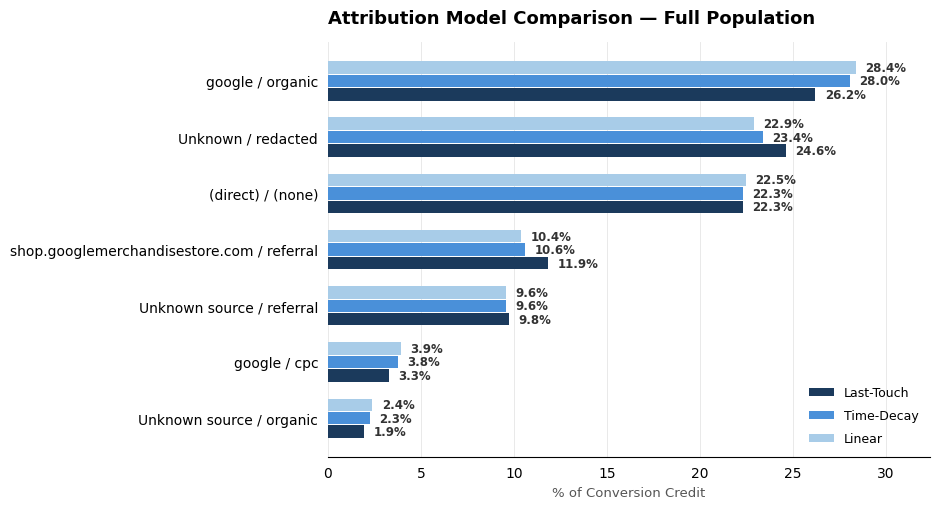

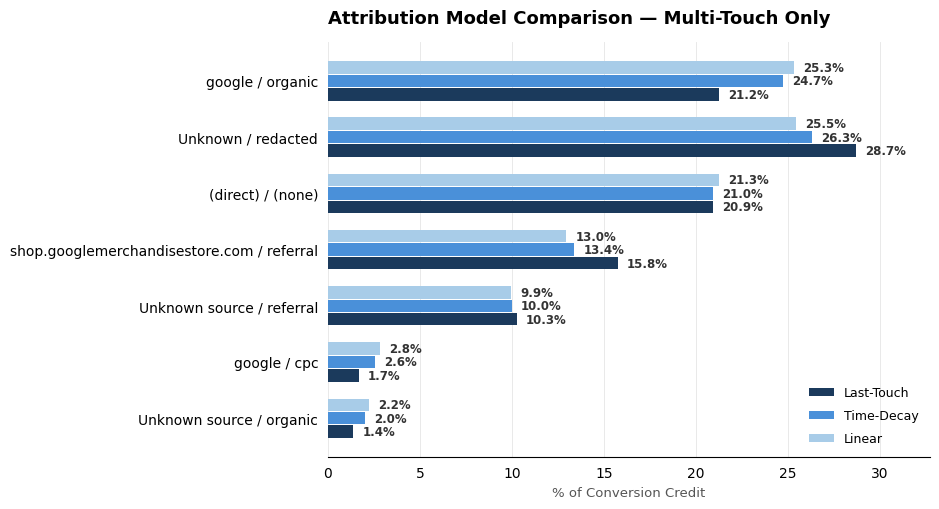

In [16]:
COLORS = {
    "Last-Touch": "#1B3A5C",
    "Time-Decay": "#4A90D9",
    "Linear": "#A8CCE8",
}

def plot_model_comparison(df, title, filename, channel_order):
    df = df.reindex(channel_order)
    channels = df.index
    y = np.arange(len(channels))
    height = 0.24

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle="-", linewidth=0.6, color="#E5E5E5")

    order = ["Last-Touch", "Time-Decay", "Linear"]
    offsets = [-height, 0, height]
    cols = {"Last-Touch": "last_click_pct", "Time-Decay": "time_decay_pct", "Linear": "linear_pct"}

    for model, offset in zip(order, offsets):
        vals = df[cols[model]]
        ax.barh(y + offset, vals, height * 0.92, label=model, color=COLORS[model], zorder=3)
        for i, v in enumerate(vals):
            ax.text(v + 0.5, y[i] + offset, f"{v:.1f}%", va="center", fontsize=8.5,
                    fontweight="bold", color="#333333")

    ax.set_yticks(y)
    ax.set_yticklabels(channels, fontsize=10)
    ax.set_xlabel("% of Conversion Credit", fontsize=9.5, color="#555555")
    ax.set_xlim(0, df[["last_click_pct", "linear_pct", "time_decay_pct"]].values.max() + 4)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14, loc="left")

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False, bottom=False)

    ax.legend(loc="lower right", frameon=False, fontsize=9, labelspacing=0.8)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

# Fixed channel order (ascending by full-population last_click_pct), shared by both charts
# so a channel's row position never shifts between the two figures.
CHANNEL_ORDER = comparison.sort_values("last_click_pct", ascending=True).index.tolist()

plot_model_comparison(comparison, "Attribution Model Comparison — Full Population",
                      "model_comparison_full.png", CHANNEL_ORDER)
plot_model_comparison(comparison_multi, "Attribution Model Comparison — Multi-Touch Only",
                      "model_comparison_multitouch.png", CHANNEL_ORDER)

## So What

For an ecommerce retailer with a channel mix like the Google Merchandise Store's (heavy organic/direct traffic, meaningful referral presence), evaluating channel performance purely through last-touch conversion counts would systematically underweight organic search's contribution to the funnel and overweight referral's. Organic brings people in but rarely gets to close the sale; referral tends to arrive after the decision is largely made.

This doesn't mean blindly reallocating budget toward organic. This analysis measures how credit is *distributed* across models, not return on ad spend, so it can't support a dollar-for-dollar reallocation claim on its own. What it does support: before making a budget decision that affects organic or paid search investment, that decision should be informed by a multi-touch model (Linear or Time-Decay), not Last-Touch alone, and that decision matters most for the segment with longer, multi-touch consideration journeys rather than the roughly half of customers who convert in a single session.

Full write-up, methodology notes, and the Tableau dashboard: see the project [README](../README.md).